In [7]:


import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt


(X_train,y_train),(X_test,y_test)=tf.keras.datasets.cifar10.load_data()


In [27]:
import numpy as np
X_train_flattened=np.reshape(X_train,(50000,(32*32*3)))#we convert to 1D because we are using a dense neural net and not CNN's
X_train_flattened_scaled=X_train_flattened/np.max(X_train_flattened)#we flatten to make our model converge faster in less epochs,accuracy is better
X_test_flattened=np.reshape(X_test,(10000,(32*32*3)))
X_test_flattened_scaled=X_test_flattened/np.max(X_train_flattened)




In [28]:


#since I want to use categorical_crossentropy,I have to one-hot encode,the target label
from tensorflow.keras.utils import to_categorical
y_train_encoded=to_categorical(y_train)
y_test_encoded=to_categorical(y_test)


In [10]:
#Training the model
model=keras.Sequential([keras.layers.Dense(units=1024,activation='relu',input_shape=(3072,)),keras.layers.Dense(units=512,activation='relu'),
                        keras.layers.Dropout(0.5),
                        keras.layers.Dense(units=256,activation='relu'),
                        keras.layers.Dropout(0.5),
                        keras.layers.Dense(units=10,activation='sigmoid')])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(X_train_flattened_scaled,y_train_encoded,epochs=10)


C:\Users\Omojire\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 52ms/step - accuracy: 0.2614 - loss: 2.0112
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.3362 - loss: 1.8409
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.3527 - loss: 1.8004
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.3662 - loss: 1.7742
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 53ms/step - accuracy: 0.3721 - loss: 1.7551
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 56ms/step - accuracy: 0.3756 - loss: 1.7347
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.3797 - loss: 1.7294
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.3846 - loss: 1.7159
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.3904 - loss: 1.7020
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.3921 - loss: 1.6998


In [45]:
print(model.evaluate(X_test_flattened_scaled,y_test_encoded))
y_predicted = model.predict(X_test_flattened_scaled)
y_predicted=np.argmax(y_predicted,axis=1)
print(y_predicted)




313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4033 - loss: 1.6645
[1.664487361907959, 0.4032999873161316]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[6 9 8 ... 5 2 7]


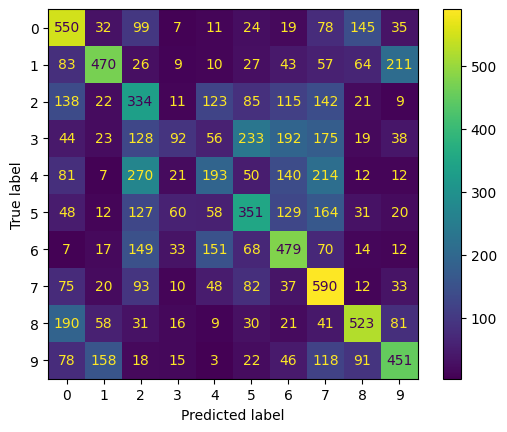

In [30]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_predicted)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()



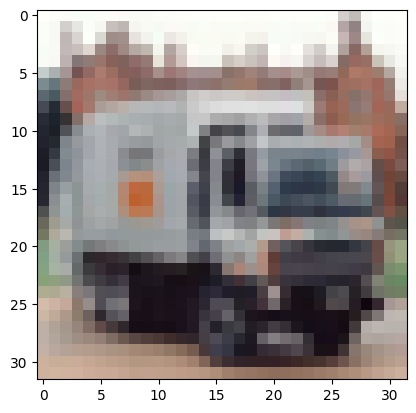

In [38]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
image=X_test_flattened_scaled[11].reshape(32,32,3)
plt.imshow(image)